In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

from google.colab import files

sns.set_style("whitegrid")

def save_plot(fig, filename):

    path = f"{filename}.eps"
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")


In [2]:
import subprocess
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

subprocess.run(
    'echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections',
    shell=True
)
result = subprocess.run(
    "apt-get update -qq && apt-get install -y ttf-mscorefonts-installer",
    shell=True, capture_output=True, text=True
)
print(result.stdout[-1000:])
print(result.stderr[-1000:])

subprocess.run("rm -rf ~/.cache/matplotlib", shell=True)
subprocess.run("fc-cache -f", shell=True, capture_output=True)

for f in fm.findSystemFonts():
    if 'times' in f.lower():
        fm.fontManager.addfont(f)

available = {f.name for f in fm.fontManager.ttflist}
print("\nIs 'Times New Roman' actually installed?", "Times New Roman" in available)

if "Times New Roman" in available:
    plt.rcParams['font.family'] = 'Times New Roman'
else:

    subprocess.run("apt-get install -y fonts-liberation", shell=True, capture_output=True)
    subprocess.run("rm -rf ~/.cache/matplotlib && fc-cache -f", shell=True, capture_output=True)
    for f in fm.findSystemFonts():
        if 'liberationserif' in f.lower():
            fm.fontManager.addfont(f)
    plt.rcParams['font.family'] = 'Liberation Serif'
    print("Times New Roman unavailable — using Liberation Serif instead "
          "(visually identical, same character widths, free to redistribute).")

plt.rcParams['mathtext.fontset'] = 'stix'
print("\nFinal font in use:", plt.rcParams['font.family'])



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: dpkg was interrupted, you must manually run 'dpkg --configure -a' to correct the problem. 


Is 'Times New Roman' actually installed? False
Times New Roman unavailable — using Liberation Serif instead (visually identical, same character widths, free to redistribute).

Final font in use: ['Liberation Serif']


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv(url, header=None, names=columns)

print("First five samples:")
display(df.head())

print("\nDataset dimensions:", df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())


First five samples:


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Dataset dimensions: (1372, 5)

Missing values per column:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive statistics:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: histograms.eps


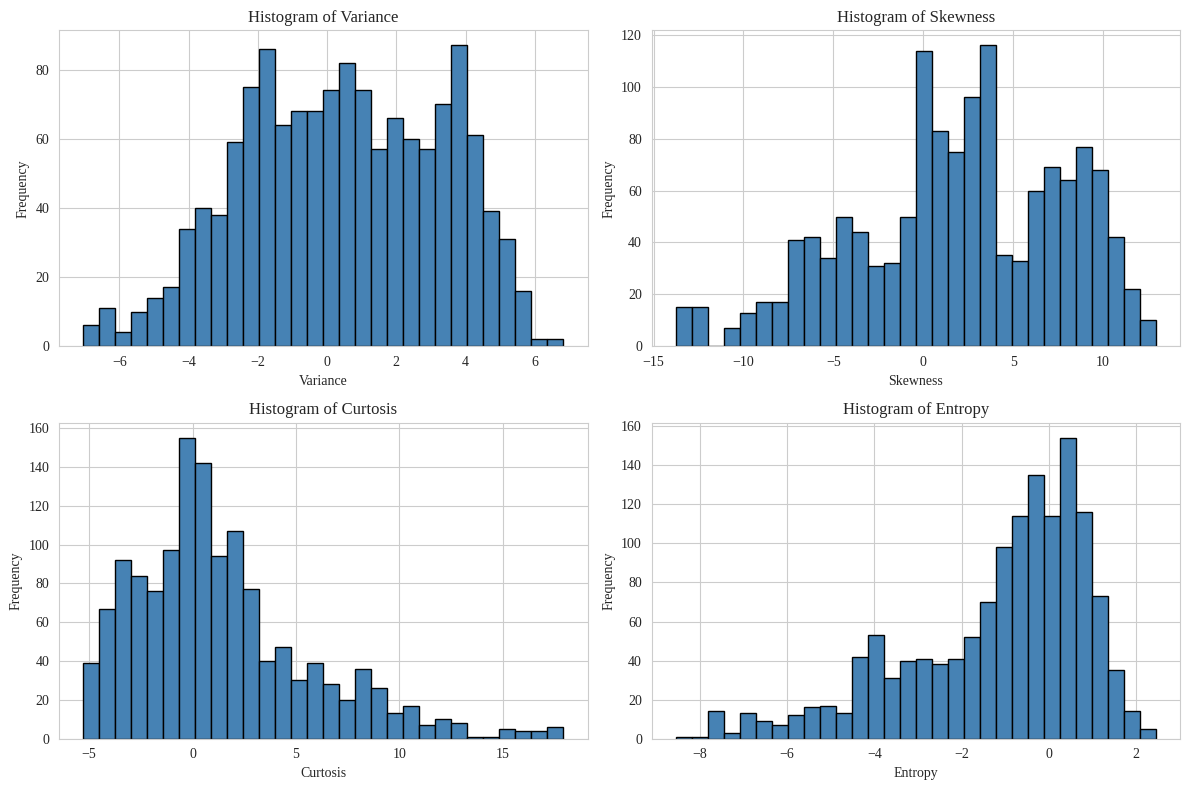

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), columns[:-1]):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
save_plot(fig, "histograms")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: correlation_heatmap.eps


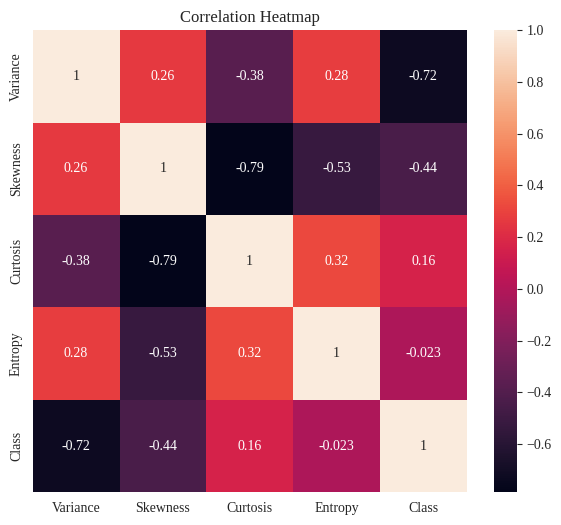

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, ax=ax)
ax.set_title("Correlation Heatmap")
save_plot(fig, "correlation_heatmap")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: scatter_plot.eps


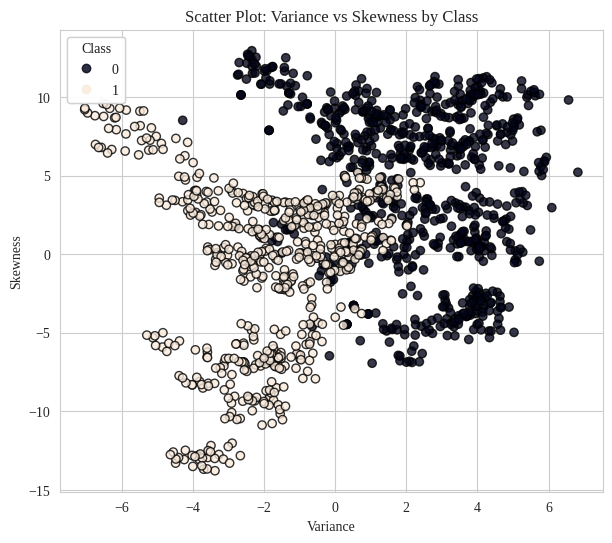

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(df['Variance'], df['Skewness'], c=df['Class'], edgecolor='k', alpha=0.8)
ax.set_xlabel("Variance")
ax.set_ylabel("Skewness")
ax.set_title("Scatter Plot: Variance vs Skewness by Class")
legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)
save_plot(fig, "scatter_plot")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: boxplots.eps


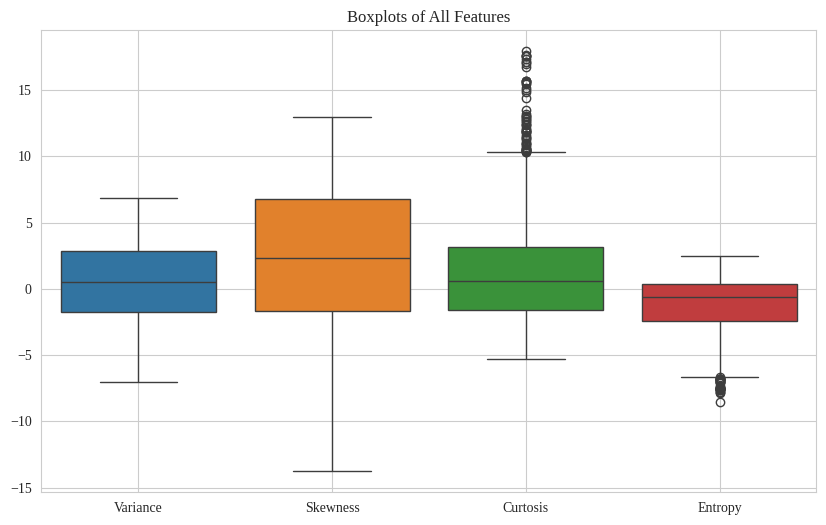

In [7]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[["Variance", "Skewness", "Curtosis", "Entropy"]])

plt.title("Boxplots of All Features")
plt.grid(True)

save_plot(plt.gcf(), "boxplots")
plt.show()


In [8]:
X = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']].values
y = df['Class'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)


Training set size: (1097, 4)
Testing set size : (275, 4)


In [9]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=100, random_state=42):
        rng = np.random.default_rng(random_state)
        self.weights = rng.normal(0, 0.01, n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.history = {'epoch': [], 'errors': [], 'weights': [], 'bias': []}

    def step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    def forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.n_epochs + 1):
            errors = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                y_hat = self.step_activation(z)
                update = self.lr * (target - y_hat)
                if update != 0:
                    self.weights += update * xi
                    self.bias += update
                    errors += 1
            self.history['epoch'].append(epoch)
            self.history['errors'].append(errors)
            self.history['weights'].append(self.weights.copy())
            self.history['bias'].append(self.bias)
            if verbose:
                print(f"Epoch {epoch:3d} | Misclassified: {errors:4d} | "
                      f"Weights: {np.round(self.weights, 4)} | Bias: {self.bias:.4f}")
            if errors == 0:
                if verbose:
                    print(f"\nConverged at epoch {epoch}.")
                break
        return self

    def predict(self, X):
        return self.forward(X)


In [10]:
model = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, n_epochs=100)
model.fit(X_train, y_train)


Epoch   1 | Misclassified:   51 | Weights: [-0.0626 -0.0793 -0.0635 -0.0028] | Bias: -0.0300
Epoch   2 | Misclassified:   24 | Weights: [-0.0762 -0.1023 -0.0646 -0.0003] | Bias: -0.0300
Epoch   3 | Misclassified:   23 | Weights: [-0.078  -0.0965 -0.0914 -0.0022] | Bias: -0.0400
Epoch   4 | Misclassified:   32 | Weights: [-0.0886 -0.1127 -0.098  -0.0056] | Bias: -0.0600
Epoch   5 | Misclassified:   26 | Weights: [-0.0967 -0.1214 -0.1062 -0.0061] | Bias: -0.0600
Epoch   6 | Misclassified:   20 | Weights: [-0.1096 -0.1347 -0.104  -0.0023] | Bias: -0.0400
Epoch   7 | Misclassified:   23 | Weights: [-0.1161 -0.1428 -0.1101 -0.0042] | Bias: -0.0500
Epoch   8 | Misclassified:   20 | Weights: [-0.1059 -0.1432 -0.1247 -0.0002] | Bias: -0.0700
Epoch   9 | Misclassified:   23 | Weights: [-0.1249 -0.1533 -0.1172  0.0035] | Bias: -0.0600
Epoch  10 | Misclassified:   18 | Weights: [-0.1199 -0.1608 -0.1236  0.0092] | Bias: -0.0600
Epoch  11 | Misclassified:   17 | Weights: [-0.1248 -0.1561 -0.1333  0

In [11]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nConfusion Matrix:\n", cm)


Accuracy : 0.9818
Precision: 0.9606
Recall   : 1.0000
F1-score : 0.9799

Confusion Matrix:
 [[148   5]
 [  0 122]]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: confusion_matrix.eps


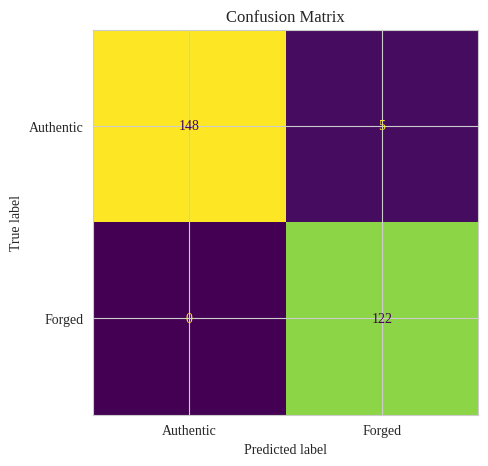

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Authentic', 'Forged'])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix")
save_plot(fig, "confusion_matrix")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: training_error_vs_epoch.eps


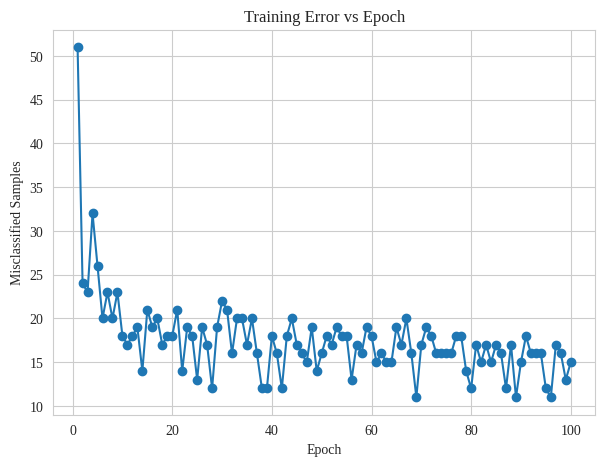

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(model.history['epoch'], model.history['errors'], marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified Samples")
ax.set_title("Training Error vs Epoch")
save_plot(fig, "training_error_vs_epoch")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: weight_evolution.eps


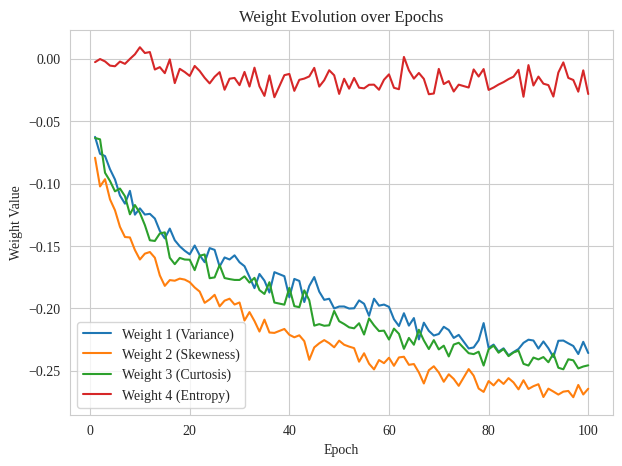

In [14]:
weights_history = np.array(model.history['weights'])

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(weights_history.shape[1]):
    ax.plot(model.history['epoch'], weights_history[:, i], label=f'Weight {i+1} ({columns[i]})')
ax.set_xlabel("Epoch")
ax.set_ylabel("Weight Value")
ax.set_title("Weight Evolution over Epochs")
ax.legend()
save_plot(fig, "weight_evolution")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: bias_evolution.eps


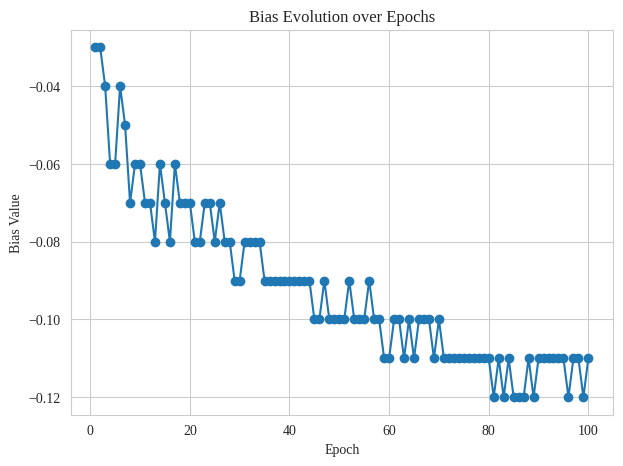

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(model.history['epoch'], model.history['bias'], marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Bias Value")
ax.set_title("Bias Evolution over Epochs")
save_plot(fig, "bias_evolution")
plt.show()


Learning Rate 0.001  | Epochs to converge/stop: 100 | Test Accuracy: 0.9855
Learning Rate 0.01   | Epochs to converge/stop: 100 | Test Accuracy: 0.9818


Learning Rate 0.1    | Epochs to converge/stop: 100 | Test Accuracy: 0.9818


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: learning_rate_comparison.eps


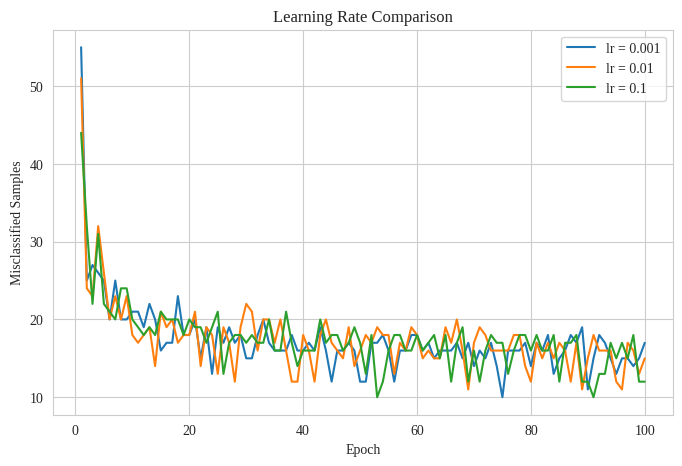

In [16]:
learning_rates = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=100)
    m.fit(X_train, y_train, verbose=False)
    lr_histories[lr] = m.history['errors']
    y_pred_lr = m.predict(X_test)
    print(f"Learning Rate {lr:<6} | Epochs to converge/stop: {len(m.history['errors']):3d} | "
          f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
for lr, errors in lr_histories.items():
    ax.plot(range(1, len(errors) + 1), errors, label=f"lr = {lr}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified Samples")
ax.set_title("Learning Rate Comparison")
ax.legend()
save_plot(fig, "learning_rate_comparison")
plt.show()


In [17]:
summary = pd.DataFrame({
    "Metric": ["Dataset Size", "Train Size", "Test Size", "Learning Rate", "Epochs Run",
               "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [len(df), X_train.shape[0], X_test.shape[0], model.lr, len(model.history['errors']),
              round(model.bias, 4), round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]
})
display(summary)

print("Final Weights:", np.round(model.weights, 4))


,Metric,Value
0,Dataset Size,1372.0000
1,Train Size,1097.0000
2,Test Size,275.0000
3,Learning Rate,0.0100
4,Epochs Run,100.0000
5,Final Bias,-0.1100
6,Accuracy,0.9818
7,Precision,0.9606
8,Recall,1.0000
9,F1-score,0.9799


Final Weights: [-0.2357 -0.2643 -0.2456 -0.0283]


In [18]:
epoch_table = pd.DataFrame({
    "Epoch": model.history['epoch'],
    "Errors": model.history['errors'],
    "Weight 1 (Variance)": weights_history[:, 0],
    "Weight 2 (Skewness)": weights_history[:, 1],
    "Bias": model.history['bias']
})
display(epoch_table)


,Epoch,Errors,Weight 1 (Variance),Weight 2 (Skewness),Bias
0,1,51,-0.062639,-0.079346,-0.03
1,2,24,-0.076201,-0.102321,-0.03
2,3,23,-0.078001,-0.096537,-0.04
3,4,32,-0.088552,-0.112673,-0.06
4,5,26,-0.096734,-0.121424,-0.06
...,...,...,...,...,...
95,96,11,-0.227976,-0.266102,-0.12
96,97,17,-0.230096,-0.271124,-0.11
97,98,16,-0.236539,-0.261297,-0.11
98,99,13,-0.226751,-0.268926,-0.12


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: step_vs_sigmoid.eps


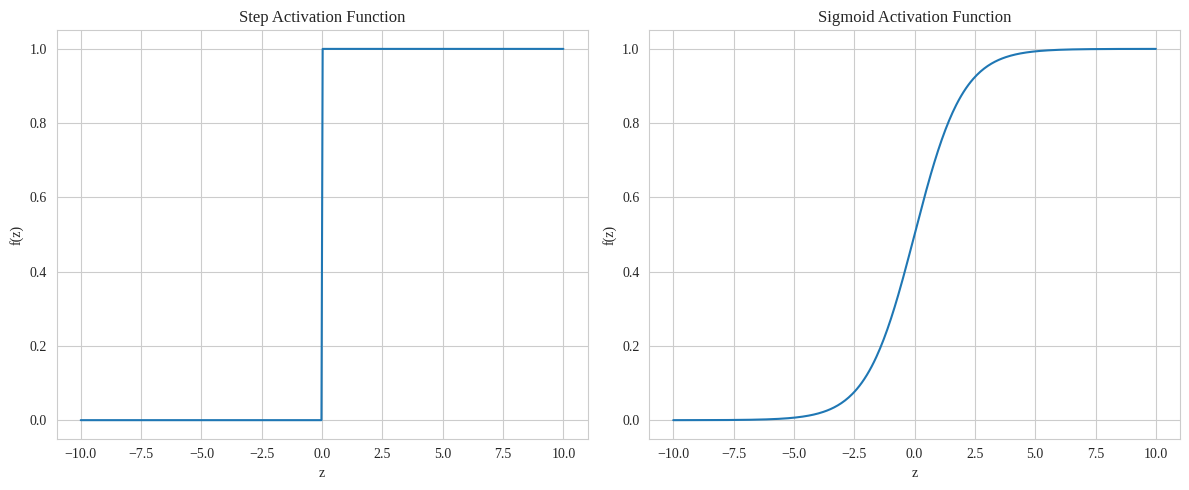

In [19]:
z = np.linspace(-10, 10, 400)
step_output = np.where(z >= 0, 1, 0)
sigmoid_output = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(z, step_output)
axes[0].set_title("Step Activation Function")
axes[0].set_xlabel("z"); axes[0].set_ylabel("f(z)")

axes[1].plot(z, sigmoid_output)
axes[1].set_title("Sigmoid Activation Function")
axes[1].set_xlabel("z"); axes[1].set_ylabel("f(z)")

plt.tight_layout()
save_plot(fig, "step_vs_sigmoid")
plt.show()


In [20]:
from sklearn.linear_model import Perceptron as SklearnPerceptron

sk_model = SklearnPerceptron(max_iter=100, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

print("Scratch Implementation Accuracy  :", accuracy_score(y_test, y_pred))
print("Scikit-learn Perceptron Accuracy :", accuracy_score(y_test, y_pred_sklearn))
print("\nScikit-learn Final Weights:", np.round(sk_model.coef_.flatten(), 4))
print("Scikit-learn Final Bias   :", np.round(sk_model.intercept_[0], 4))


Scratch Implementation Accuracy  : 0.9818181818181818
Scikit-learn Perceptron Accuracy : 0.9745454545454545

Scikit-learn Final Weights: [-0.1169 -0.1422 -0.1107  0.005 ]
Scikit-learn Final Bias   : -0.03


In [21]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

xor_model = Perceptron(n_features=2, learning_rate=0.1, n_epochs=50)
xor_model.fit(X_xor, y_xor, verbose=False)
y_xor_pred = xor_model.predict(X_xor)

print("XOR Inputs:\n", X_xor)
print("XOR Targets:  ", y_xor)
print("Predicted:    ", y_xor_pred)
print("Accuracy on XOR:", accuracy_score(y_xor, y_xor_pred))
print("Misclassified samples per epoch (last 10):", xor_model.history['errors'][-10:])


XOR Inputs:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
XOR Targets:   [0 1 1 0]
Predicted:     [1 0 0 0]
Accuracy on XOR: 0.25
Misclassified samples per epoch (last 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: normalization_effect.eps


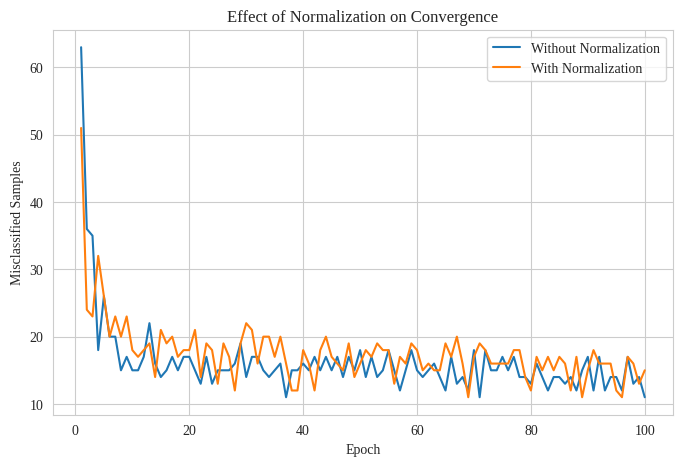

Epochs to converge/stop (raw features)       : 100
Epochs to converge/stop (normalized features) : 100


In [22]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_raw = Perceptron(n_features=X.shape[1], learning_rate=0.01, n_epochs=100)
model_raw.fit(X_train_raw, y_train_raw, verbose=False)

model_norm = Perceptron(n_features=X.shape[1], learning_rate=0.01, n_epochs=100)
model_norm.fit(X_train, y_train, verbose=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(model_raw.history['epoch'], model_raw.history['errors'], label='Without Normalization')
ax.plot(model_norm.history['epoch'], model_norm.history['errors'], label='With Normalization')
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified Samples")
ax.set_title("Effect of Normalization on Convergence")
ax.legend()
save_plot(fig, "normalization_effect")
plt.show()

print("Epochs to converge/stop (raw features)       :", len(model_raw.history['errors']))
print("Epochs to converge/stop (normalized features) :", len(model_norm.history['errors']))
